# 机器学习实验二：基于 PyTorch 的手写数字识别

这份 notebook 分为两部分：

1. **基线示例**  
   前半部分提供一个完整可运行的基线模型，包含数据加载、数据预处理、模型构建、训练、验证、测试和曲线绘制等流程。  
   请先完整运行这一部分，理解深度学习实验的基本流程。

2. **学生实验模板**  
   后半部分用于完成调参与对比实验。  
   请参考基线示例，在指定位置修改参数、补充代码、运行实验，并记录结果。

使用建议：

- 先从上到下运行基线示例，确认环境和代码可以正常运行。
- 再阅读封装好的训练与评估函数，理解它们在后续实验中的作用。
- 最后完成 batch size、隐藏层层数、神经元数量、激活函数和 Dropout 等单变量对比实验。
- 附加题为选做内容，可根据兴趣和时间完成。

## 一、基线示例

目标：先跑通一个最简单的全连接 BP 神经网络。

流程：数据加载 → 数据预处理 → 模型构建 → 训练 → 验证 → 测试。


### 1. 导入库并设置设备


In [4]:
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import precision_score, recall_score, f1_score

import matplotlib.pyplot as plt


# 固定随机种子，方便复现实验结果。
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# 有 GPU 就使用 GPU，否则使用 CPU。
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)


使用设备: cuda


### 2. 数据预处理

`ToTensor()` 会把图片像素从 0 ~ 255 转成 0 ~ 1。  
这是因为神经网络更适合处理数值范围较小的数据，先缩放可以让训练更稳定。

`Normalize()` 会进一步做标准化，让数据分布更合适。  
标准化后，数据不再局限于 0 ~ 1，而是变成“减去均值，再除以标准差”后的结果。这样通常有助于模型更快收敛，也能让不同维度的数据处于更接近的尺度上。

可以**简单理解**为：

- `ToTensor()`：先把数值变小
- `Normalize()`：再把数据调整得更适合训练

In [5]:
# MNIST 是 1 通道灰度图，所以均值和标准差都只有一个数。
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)

transform = transforms.Compose([
    transforms.ToTensor(),                         # 0~255 -> 0~1
    transforms.Normalize(MNIST_MEAN, MNIST_STD),   # 标准化
])


### 3. 加载数据集并划分验证集

原始 MNIST 训练集有 60000 张图片。

这里划分为：

- 50000 张：训练集，用来更新模型参数
- 10000 张：验证集，用来调参和画曲线

测试集保留到最后使用。


In [6]:
# 下载并读取 MNIST 数据集。
train_full = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

TRAIN_SIZE = 50000   # 用于训练
VAL_SIZE = 10000     # 用于调参与画曲线

# 使用固定随机种子划分，保证每次运行划分结果一致。
train_dataset, val_dataset = random_split(
    train_full,
    [TRAIN_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(SEED)
)

print("训练集样本数:", len(train_dataset))
print("验证集样本数:", len(val_dataset))
print("测试集样本数:", len(test_dataset))


100.0%
100.0%
100.0%
100.0%

训练集样本数: 50000
验证集样本数: 10000
测试集样本数: 10000


### 4. 设置基线参数

下面这组参数用于设置**基线实验**。  
建议先使用这组参数完整运行一次，得到基线结果，作为后续对比实验的参照。

基线模型结构为：

`Flatten → Linear(784, 128) → ReLU → Linear(128, 10)`


In [7]:
# 基线参数：不建议修改。
batch_size = 64
hidden_dim = 128
learning_rate = 0.001
epochs = 5


### 5. 创建 DataLoader

DataLoader 负责把数据按 batch 送入模型。


In [8]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("每个 batch 的样本数:", batch_size)
print("训练集 batch 数量:", len(train_loader))


每个 batch 的样本数: 64
训练集 batch 数量: 782


### 6. 搭建基线 BP 神经网络模型

注意：本实验使用 `nn.CrossEntropyLoss()`，模型最后一层直接输出 logits，不需要加 `Softmax`。


In [9]:
baseline_model = nn.Sequential(
    nn.Flatten(),                 # [batch_size, 1, 28, 28] -> [batch_size, 784]
    nn.Linear(784, hidden_dim),    # 第 1 个全连接层
    nn.ReLU(),                    # 激活函数
    nn.Linear(hidden_dim, 10),     # 输出层：10 类数字
).to(device)

print(baseline_model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


### 7. 训练并验证基线模型

下面这段代码是最直观的训练流程。  
每个 epoch 包括：

1. 在训练集上训练模型
2. 在验证集上评估模型
3. 保存并打印本轮的 loss、accuracy 和耗时


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=learning_rate)

# 用 history 保存每个 epoch 的结果，后面用于打印表格和画曲线。
baseline_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": [],
}

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # ========== 训练阶段 ==========
    baseline_model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        # 1. 清空上一轮梯度，避免梯度累积
        optimizer.zero_grad()

        # 2. 前向传播，得到模型输出
        output = baseline_model(data)

        # 3. 计算损失
        loss = criterion(output, target)

        # 4. 反向传播并更新参数
        loss.backward()
        optimizer.step()

        # 5. 统计本 batch 的 loss 和准确率
        train_loss_sum += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        train_correct += (pred == target).sum().item()
        train_total += target.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = 100 * train_correct / train_total

    # ========== 验证阶段 ==========
    baseline_model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = baseline_model(data)
            loss = criterion(output, target)

            val_loss_sum += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            val_correct += (pred == target).sum().item()
            val_total += target.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time

    # ========== 保存结果 ==========
    baseline_history["epoch"].append(epoch)
    baseline_history["train_loss"].append(train_loss)
    baseline_history["train_acc"].append(train_acc)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)
    baseline_history["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
        f"time={epoch_time:.2f}s"
    )

print(f"训练总耗时: {sum(baseline_history['epoch_time']):.2f} 秒")


Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=7.09s
Epoch 02/5 | train_loss=0.1183, train_acc=96.58% | val_loss=0.1245, val_acc=96.11% | time=7.28s
Epoch 03/5 | train_loss=0.0816, train_acc=97.52% | val_loss=0.1184, val_acc=96.37% | time=8.84s
Epoch 04/5 | train_loss=0.0612, train_acc=98.12% | val_loss=0.0944, val_acc=97.09% | time=3.75s
Epoch 05/5 | train_loss=0.0466, train_acc=98.55% | val_loss=0.0873, val_acc=97.47% | time=7.66s
训练总耗时: 34.63 秒


### 8. 查看基线实验结果

报告截图建议包含：

- 每个 epoch 的输出
- 最后 3 个 epoch 的表格
- loss 曲线和 accuracy 曲线


In [11]:
print("最后 3 个 epoch 结果：")

header = f"{'epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>7} | {'time(s)':>7}"
print(header)
print("-" * len(header))

start = max(0, len(baseline_history["epoch"]) - 3)
for i in range(start, len(baseline_history["epoch"])):
    print(
        f"{baseline_history['epoch'][i]:>5} | "
        f"{baseline_history['train_loss'][i]:>10.4f} | "
        f"{baseline_history['train_acc'][i]:>8.2f}% | "
        f"{baseline_history['val_loss'][i]:>8.4f} | "
        f"{baseline_history['val_acc'][i]:>6.2f}% | "
        f"{baseline_history['epoch_time'][i]:>7.2f}"
    )


最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0816 |    97.52% |   0.1184 |  96.37% |    8.84
    4 |     0.0612 |    98.12% |   0.0944 |  97.09% |    3.75
    5 |     0.0466 |    98.55% |   0.0873 |  97.47% |    7.66


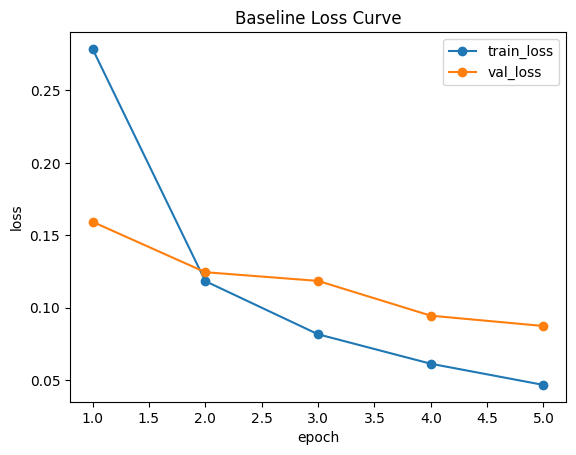

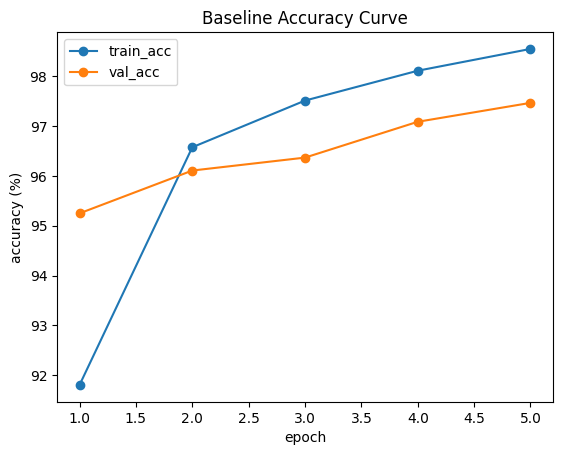

In [12]:
# 绘制 loss 曲线
plt.figure()
plt.plot(baseline_history["epoch"], baseline_history["train_loss"], marker="o", label="train_loss")
plt.plot(baseline_history["epoch"], baseline_history["val_loss"], marker="o", label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Baseline Loss Curve")
plt.legend()
plt.show()

# 绘制 accuracy 曲线
plt.figure()
plt.plot(baseline_history["epoch"], baseline_history["train_acc"], marker="o", label="train_acc")
plt.plot(baseline_history["epoch"], baseline_history["val_acc"], marker="o", label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy (%)")
plt.title("Baseline Accuracy Curve")
plt.legend()
plt.show()


### 9. 在测试集上评估基线模型

调参阶段主要看验证集。  
测试集建议只在基线模型或最终选定模型上评估。


In [13]:
baseline_model.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0

all_targets = []
all_preds = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        output = baseline_model(data)
        loss = criterion(output, target)

        test_loss_sum += loss.item() * data.size(0)

        pred = output.argmax(dim=1)

        test_correct += (pred == target).sum().item()
        test_total += target.size(0)

        all_targets.extend(target.cpu().numpy())
        all_preds.extend(pred.cpu().numpy())

baseline_test_loss = test_loss_sum / test_total
baseline_test_acc = 100 * test_correct / test_total

baseline_test_precision = precision_score(all_targets, all_preds, average='macro')
baseline_test_recall = recall_score(all_targets, all_preds, average='macro')
baseline_test_f1 = f1_score(all_targets, all_preds, average='macro')

print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_acc:.2f}%")
print(f"Baseline test precision (macro): {baseline_test_precision:.4f}")
print(f"Baseline test recall (macro): {baseline_test_recall:.4f}")
print(f"Baseline test f1-score (macro): {baseline_test_f1:.4f}")


Baseline test loss: 0.0778
Baseline test accuracy: 97.63%
Baseline test precision (macro): 0.9762
Baseline test recall (macro): 0.9761
Baseline test f1-score (macro): 0.9761


## 二、为了方便后续**调参**实验，封装统一实验函数

前面已经用较为直观的方式完成了一次基线实验，便于理解完整训练流程。  
为了让后续调参与对比实验更方便、代码更简洁，下面将基线实验的主要流程整理成统一实验函数 `run_experiment(...)`。

从后面的实验开始，学生主要通过**修改调用 `run_experiment(...)` 时传入的参数**来完成不同调参对比实验。


### 10. 准备几个辅助函数

下面这些函数只是把前面基线代码中的重复部分整理出来。  
一般**不需要修改**这些函数，理解它们的作用即可。


In [14]:
def set_seed(seed=SEED):
    """固定随机种子，尽量减少实验中的随机因素。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_dataloaders(batch_size):
    """根据 batch_size 创建训练集、验证集和测试集 DataLoader。"""
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def get_activation(name):
    """根据名称返回激活函数。"""
    name = name.lower()

    if name == "relu":
        return nn.ReLU()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "tanh":
        return nn.Tanh()
    if name == "leaky_relu":
        return nn.LeakyReLU()

    raise ValueError("activation_name 只能是 relu / sigmoid / tanh / leaky_relu")


def build_mlp(hidden_dims=None, activation_name="relu", dropout_p=0.0):
    """
    构建全连接 BP 神经网络。

    参数说明：
    - hidden_dims: 隐藏层神经元数量列表，例如 [128]、[128, 128, 128]
    - activation_name: 激活函数名称
    - dropout_p: Dropout 概率，0.0 表示不使用 Dropout
    """
    if hidden_dims is None:
        hidden_dims = [128]

    layers = [nn.Flatten()]      # [batch_size, 1, 28, 28] -> [batch_size, 784]
    input_dim = 784

    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(get_activation(activation_name))

        if dropout_p > 0:
            layers.append(nn.Dropout(p=dropout_p))

        input_dim = hidden_dim

    layers.append(nn.Linear(input_dim, 10))  # 输出 10 个 logits，对应数字 0~9
    return nn.Sequential(*layers)


### 11. 训练、评估与结果记录函数

这些函数对应基线代码中的三个动作：

- `train_one_epoch(...)`：训练一个 epoch
- `evaluate(...)`：在验证集或测试集上评估
- `record_history(...)`：把每个 epoch 的结果保存下来，后续展示


In [15]:
def train_one_epoch(model, loader, optimizer, criterion):
    """训练一个 epoch，返回训练 loss 和训练 accuracy。"""
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for data, target in loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    """评估模型，返回 loss 和 accuracy。"""
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)

    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    return avg_loss, accuracy


def init_history():
    """初始化一个 history，用来保存每个 epoch 的结果。"""
    return {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": [],
    }


def record_history(history, epoch, train_loss, train_acc, val_loss, val_acc, epoch_time):
    """把当前 epoch 的训练/验证结果保存到 history 中。"""
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["epoch_time"].append(epoch_time)


### 12. 定义统一实验函数 `run_experiment(...)`

`run_experiment(...)` 是后续调参与对比实验的统一入口。  
学生做调参实验时，主要通过**修改调用该函数时传入的参数**来完成。

注意遵守**控制变量法**：

- 每次只改变一个超参数，其他参数保持不变
- 例如比较不同 `batch_size` 时，不要同时修改 `hidden_dims`、`activation_name` 或 `dropout_p`


In [16]:
def run_experiment(
    exp_name="baseline",
    batch_size=64,
    hidden_dims=None,
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
):
    """
    运行一组实验。

    返回：
    - model: 训练好的模型
    - history: 每个 epoch 的训练/验证结果
    - test_loader: 测试集加载器，供后续最终评估使用
    """
    if hidden_dims is None:
        hidden_dims = [128]

    # 每组实验重新固定随机种子，减少随机因素影响。
    set_seed(SEED)

    # 根据参数创建数据、模型、损失函数和优化器。
    train_loader, val_loader, test_loader = make_dataloaders(batch_size)
    model = build_mlp(hidden_dims, activation_name, dropout_p).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = init_history()

    if verbose:
        print("=" * 72)
        print("实验名称:", exp_name)
        print("batch_size:", batch_size)
        print("hidden_dims:", hidden_dims)
        print("activation_name:", activation_name)
        print("dropout_p:", dropout_p)
        print("learning_rate:", learning_rate)
        print("epochs:", epochs)
        print("=" * 72)

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        epoch_time = time.time() - start_time
        record_history(history, epoch, train_loss, train_acc, val_loss, val_acc, epoch_time)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
                f"time={epoch_time:.2f}s"
            )

    if verbose:
        print(f"训练总耗时: {sum(history['epoch_time']):.2f} 秒")

    return model, history, test_loader


### 13. 结果展示函数

这几个函数用于截图和画图：

- `print_history_table(...)`：打印最后几个 epoch 的结果表格
- `plot_history(...)`：绘制单组实验的 loss 和 accuracy 曲线
- `plot_compare(...)`：绘制多组实验的单指标对比曲线
- `plot_compare_grid(...)`：以 2×2 子图统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类对比曲线


In [17]:
def print_history_table(history, last_n=None):
    """打印训练结果表格。last_n=None 表示打印全部 epoch。"""
    total_epochs = len(history["epoch"])
    start = 0 if last_n is None else max(0, total_epochs - last_n)

    header = f"{'epoch':>5} | {'train_loss':>10} | {'train_acc':>9} | {'val_loss':>8} | {'val_acc':>7} | {'time(s)':>7}"
    print(header)
    print("-" * len(header))

    for i in range(start, total_epochs):
        print(
            f"{history['epoch'][i]:>5} | "
            f"{history['train_loss'][i]:>10.4f} | "
            f"{history['train_acc'][i]:>8.2f}% | "
            f"{history['val_loss'][i]:>8.4f} | "
            f"{history['val_acc'][i]:>6.2f}% | "
            f"{history['epoch_time'][i]:>7.2f}"
        )


def plot_history(history, title_prefix=""):
    """绘制单组实验的 loss 和 accuracy 曲线。"""
    epoch_list = history["epoch"]

    plt.figure()
    plt.plot(epoch_list, history["train_loss"], marker="o", label="train_loss")
    plt.plot(epoch_list, history["val_loss"], marker="o", label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title_prefix} Loss Curve")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epoch_list, history["train_acc"], marker="o", label="train_acc")
    plt.plot(epoch_list, history["val_acc"], marker="o", label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy (%)")
    plt.title(f"{title_prefix} Accuracy Curve")
    plt.legend()
    plt.show()


def plot_compare(histories, metric="val_acc", title="Compare"):
    """
    绘制多组实验的某一个指标对比曲线。

    histories 格式示例：
    {
        "batch_size=32": history_32,
        "batch_size=64": history_64,
    }
    """
    plt.figure()
    for name, history in histories.items():
        plt.plot(history["epoch"], history[metric], marker="o", label=name)

    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_compare_grid(histories, title_prefix="Compare"): 
    """ 以 2×2 子图统一绘制 train/val 的 loss 与 accuracy 对比曲线。"""
    metrics = [
        ("train_loss", "Training Loss"),
        ("val_loss", "Validation Loss"),
        ("train_acc", "Training Accuracy"),
        ("val_acc", "Validation Accuracy"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    for ax, (metric, subtitle) in zip(axes, metrics):
        for name, history in histories.items():
            ax.plot(history["epoch"], history[metric], marker="o", label=name)

        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.set_title(f"{title_prefix} - {subtitle}")
        ax.legend()

    plt.tight_layout()
    plt.show()


## 三、学生调参与对比实验

从这里开始是动手完成实验的部分。  
前面已经定义好了 `run_experiment(...)`，它可以减少重复训练代码，但**不会自动替你完成所有实验**。

每个练习只给出**一组示例代码**，请你仿照示例，自己补充其余实验组，并完成结果记录、截图和分析。

实验要求：

- 遵守**控制变量法**：每次只改变一个超参数，其他参数保持与基线一致
- 要完成 `batch size / 网络深度 / 神经元数量 / 激活函数 / Dropout` 这 **5 类单变量实验**。
- **每一类实验**都要绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。
- 完成 5 类单变量实验后，再做一次“**不同调参方向的最佳单变量结果对比**”，并绘制上述 4 类曲线。
- 将关键结果、曲线和分析写入实验报告


### 练习 1：不同 batch size 对比

要求比较：`32`、`64`、`128`。  
其他参数保持和基线一致。

下面只给出 `batch_size=32` 的示例，请仿照补充 `batch_size=64` 和 `batch_size=128`。  


In [18]:
# 示例：batch_size = 32
model_bs32, history_bs32, _ = run_experiment(
    exp_name="batch_size=32",
    batch_size=32,          # 本练习只修改 batch_size
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
batch_size_histories = {}
batch_size_histories["batch_size=32"] = history_bs32
batch_size_configs = {}
batch_size_configs["batch_size=32"] = {
    "batch_size": 32,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_bs32, last_n=3)


实验名称: batch_size=32
batch_size: 32
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2415, train_acc=92.76% | val_loss=0.1468, val_acc=95.60% | time=11.89s
Epoch 02/5 | train_loss=0.1075, train_acc=96.73% | val_loss=0.1211, val_acc=96.45% | time=4.46s
Epoch 03/5 | train_loss=0.0766, train_acc=97.56% | val_loss=0.1047, val_acc=96.73% | time=9.50s
Epoch 04/5 | train_loss=0.0595, train_acc=98.14% | val_loss=0.1122, val_acc=96.66% | time=10.14s
Epoch 05/5 | train_loss=0.0470, train_acc=98.46% | val_loss=0.1057, val_acc=96.92% | time=4.72s
训练总耗时: 40.70 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0766 |    97.56% |   0.1047 |  96.73% |    9.50
    4 |     0.0595 |    98.14% |   0.1122 |  96.66% |   10.14
    5 |     0.0470 |    98.46% |   0.1057 |  96.92% |    4.72


In [19]:
model_bs64, history_bs64, _ = run_experiment(
    exp_name="batch_size=64",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
batch_size_histories["batch_size=64"] = history_bs64
batch_size_configs["batch_size=64"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_bs64, last_n=3)


实验名称: batch_size=64
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=6.83s
Epoch 02/5 | train_loss=0.1183, train_acc=96.58% | val_loss=0.1245, val_acc=96.11% | time=7.23s
Epoch 03/5 | train_loss=0.0816, train_acc=97.52% | val_loss=0.1184, val_acc=96.37% | time=5.47s
Epoch 04/5 | train_loss=0.0612, train_acc=98.12% | val_loss=0.0944, val_acc=97.09% | time=3.51s
Epoch 05/5 | train_loss=0.0466, train_acc=98.55% | val_loss=0.0873, val_acc=97.47% | time=4.33s
训练总耗时: 27.37 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0816 |    97.52% |   0.1184 |  96.37% |    5.47
    4 |     0.0612 |    98.12% |   0.0944 |  97.09% |    3.51
    5 |     0.0466 |    98.55% |   0.0873 |  97.47% |    4.33


In [20]:
model_bs128, history_bs128, _ = run_experiment(
    exp_name="batch_size=128",
    batch_size=128,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
batch_size_histories["batch_size=128"] = history_bs128
batch_size_configs["batch_size=128"] = {
    "batch_size": 128,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_bs128, last_n=3)


实验名称: batch_size=128
batch_size: 128
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3257, train_acc=90.56% | val_loss=0.1873, val_acc=94.36% | time=3.38s
Epoch 02/5 | train_loss=0.1439, train_acc=95.84% | val_loss=0.1471, val_acc=95.58% | time=4.01s
Epoch 03/5 | train_loss=0.1006, train_acc=97.11% | val_loss=0.1223, val_acc=96.30% | time=7.32s
Epoch 04/5 | train_loss=0.0769, train_acc=97.65% | val_loss=0.1055, val_acc=96.86% | time=5.32s
Epoch 05/5 | train_loss=0.0592, train_acc=98.28% | val_loss=0.0955, val_acc=97.01% | time=6.25s
训练总耗时: 26.29 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1006 |    97.11% |   0.1223 |  96.30% |    7.32
    4 |     0.0769 |    97.65% |   0.1055 |  96.86% |    5.32
    5 |     0.0592 |    98.28% |   0.0955 |  97.01% |    6.25


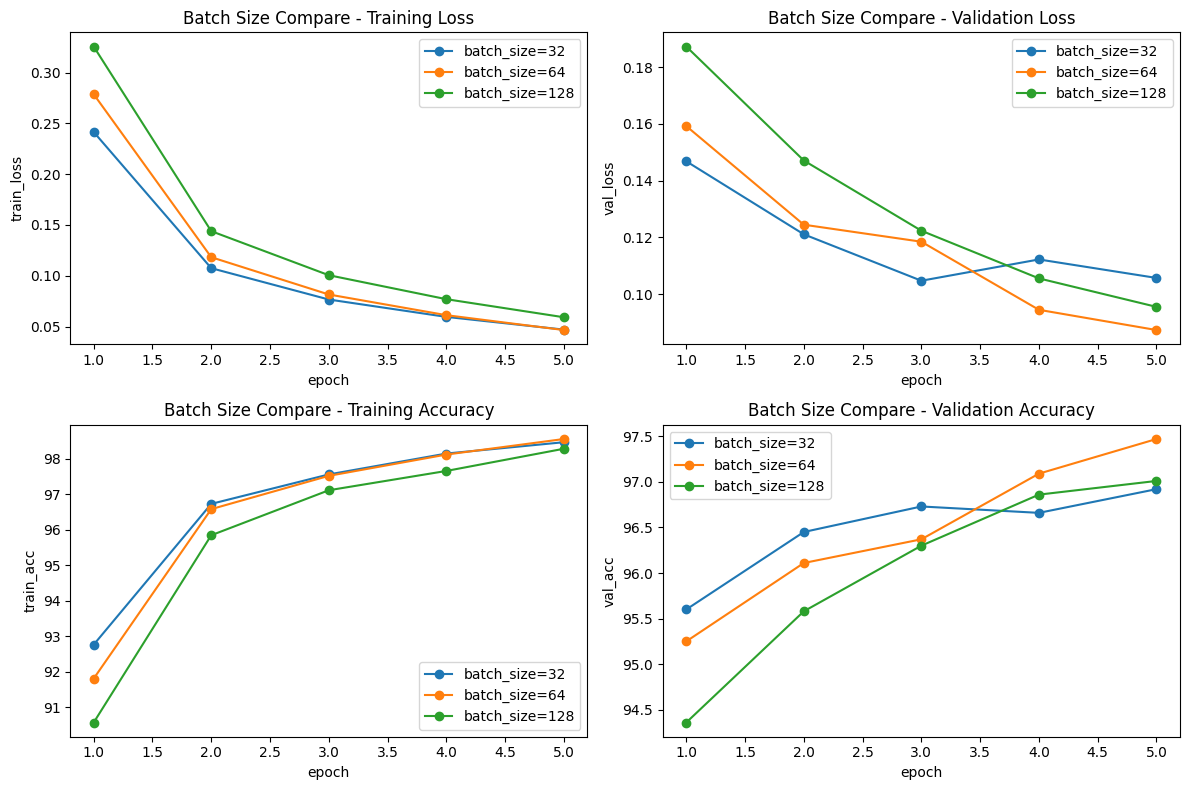

In [21]:
# 统一绘制 4 张曲线（2×2 子图，类似于下图）。
plot_compare_grid(batch_size_histories, title_prefix="Batch Size Compare")


### 如何根据曲线分析结果？

| 情况 | 曲线表现 | 说明 | 可以怎么做 |
|---|---|---|---|
| 欠拟合 | `train_loss`、`val_loss` 都较高；<br>`train_acc`、`val_acc` 都较低 | 模型还没学好 | - 增加训练轮数<br>- 增大模型规模<br>- 调整学习率<br>- 适当减小 dropout |
| 过拟合 | `train_loss` 继续下降、`train_acc` 继续上升；<br>但 `val_loss` 上升或 `val_acc` 停止提升 | 模型对训练集学得太“死” | - 提前停止训练<br>- 增加 dropout<br>- 加入正则化<br>- 做数据增强<br>- 适当减小模型规模 |
| 可以继续训练 | `val_loss` 还在下降；<br>`val_acc` 还在上升 | 模型还有提升空间 | - 继续训练<br>- 继续观察验证集变化 |
| 可以考虑停止 | `val_loss` 不再下降；<br>`val_acc` 不再提升 | 模型基本达到当前效果上限 | - 停止训练<br>- 保留验证集表现最好的模型 |
| 比较不同参数 | `val_acc` 更高；`val_loss` 更低；<br>曲线更平稳 | 调参阶段主要看验证集表现 | - 选择验证集效果更好的参数设置 |


### 练习 2：不同网络深度对比

本实验中，“网络深度”用**隐藏层层数**表示。

建议比较：

- `[128]`：1 个隐藏层
- `[128, 128, 128]`：3 个隐藏层
- `[128, 128, 128, 128, 128]`：5 个隐藏层

其他参数保持和基线一致。  
下面只给出 1 个隐藏层的示例，请仿照补充 3 个隐藏层和 5 个隐藏层。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [22]:
# 示例：1 个隐藏层
model_depth1, history_depth1, _ = run_experiment(
    exp_name="1 hidden layer",
    batch_size=64,
    hidden_dims=[128],      # 1 个隐藏层
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
depth_histories={}
depth_histories["1 hidden layer"] = history_depth1
depth_configs = {}
depth_configs["1 hidden layer"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_depth1, last_n=3)


实验名称: 1 hidden layer
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=7.97s
Epoch 02/5 | train_loss=0.1183, train_acc=96.58% | val_loss=0.1245, val_acc=96.11% | time=7.05s
Epoch 03/5 | train_loss=0.0816, train_acc=97.52% | val_loss=0.1184, val_acc=96.37% | time=7.69s
Epoch 04/5 | train_loss=0.0612, train_acc=98.12% | val_loss=0.0944, val_acc=97.09% | time=8.13s
Epoch 05/5 | train_loss=0.0466, train_acc=98.55% | val_loss=0.0873, val_acc=97.47% | time=8.08s
训练总耗时: 38.92 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0816 |    97.52% |   0.1184 |  96.37% |    7.69
    4 |     0.0612 |    98.12% |   0.0944 |  97.09% |    8.13
    5 |     0.0466 |    98.55% |   0.0873 |  97.47% |    8.08


In [23]:
model_depth3, history_depth3, _ = run_experiment(
    exp_name="3 hidden layers",
    batch_size=64,
    hidden_dims=[128, 128, 128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
depth_histories["3 hidden layers"] = history_depth3
depth_configs["3 hidden layers"] = {
    "batch_size": 64,
    "hidden_dims": [128, 128, 128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_depth3, last_n=3)


实验名称: 3 hidden layers
batch_size: 64
hidden_dims: [128, 128, 128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2863, train_acc=91.35% | val_loss=0.1671, val_acc=94.91% | time=3.85s
Epoch 02/5 | train_loss=0.1196, train_acc=96.27% | val_loss=0.1341, val_acc=95.89% | time=3.75s
Epoch 03/5 | train_loss=0.0851, train_acc=97.33% | val_loss=0.1086, val_acc=96.72% | time=3.74s
Epoch 04/5 | train_loss=0.0643, train_acc=97.90% | val_loss=0.0984, val_acc=97.13% | time=3.82s
Epoch 05/5 | train_loss=0.0527, train_acc=98.27% | val_loss=0.1071, val_acc=97.11% | time=3.64s
训练总耗时: 18.79 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0851 |    97.33% |   0.1086 |  96.72% |    3.74
    4 |     0.0643 |    97.90% |   0.0984 |  97.13% |    3.82
    5 |     0.0527 |    98.27% |   0.1071 |  97.11% |    3.64


In [24]:
model_depth5, history_depth5, _ = run_experiment(
    exp_name="5 hidden layers",
    batch_size=64,
    hidden_dims=[128, 128, 128, 128, 128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
depth_histories["5 hidden layers"] = history_depth5
depth_configs["5 hidden layers"] = {
    "batch_size": 64,
    "hidden_dims": [128, 128, 128, 128, 128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_depth5, last_n=3)


实验名称: 5 hidden layers
batch_size: 64
hidden_dims: [128, 128, 128, 128, 128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3508, train_acc=88.75% | val_loss=0.1948, val_acc=93.89% | time=3.95s
Epoch 02/5 | train_loss=0.1359, train_acc=95.79% | val_loss=0.1476, val_acc=95.89% | time=3.81s
Epoch 03/5 | train_loss=0.1010, train_acc=97.01% | val_loss=0.1318, val_acc=96.02% | time=3.75s
Epoch 04/5 | train_loss=0.0796, train_acc=97.63% | val_loss=0.1243, val_acc=96.47% | time=3.61s
Epoch 05/5 | train_loss=0.0685, train_acc=97.91% | val_loss=0.1104, val_acc=96.78% | time=3.67s
训练总耗时: 18.79 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1010 |    97.01% |   0.1318 |  96.02% |    3.75
    4 |     0.0796 |    97.63% |   0.1243 |  96.47% |    3.61
    5 |     0.0685 |    97.91% |   0.1104 |  96.78% |    3.67


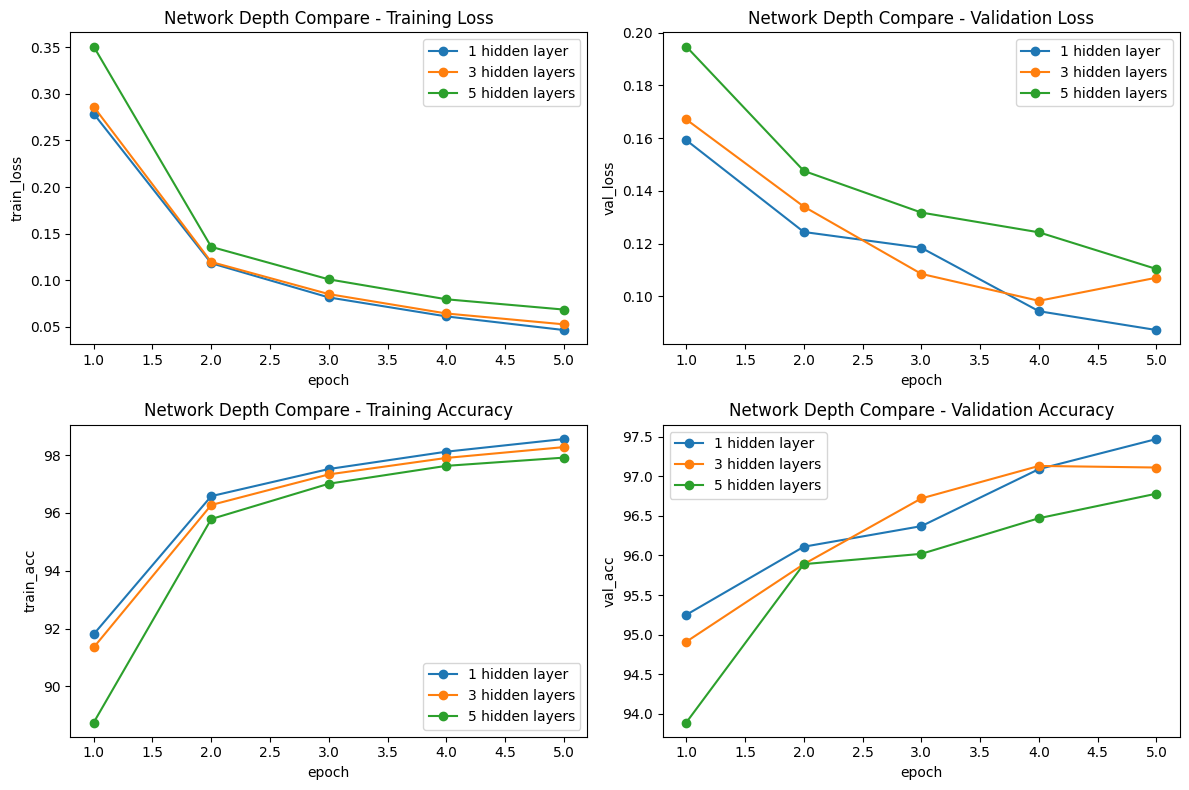

In [25]:
# 统一绘制 4 张曲线（2×2 子图，类似于下图）。
plot_compare_grid(depth_histories, title_prefix="Network Depth Compare")


### 练习 3：不同神经元数量对比

要求比较：`64`、`128`、`256`、`512`。  
这里保持 1 个隐藏层，只改变隐藏层神经元数量。

下面只给出 `hidden_dims=[64]` 的示例，请仿照补充其他神经元数量。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [26]:
# 示例：隐藏层神经元数量为 64
model_width64, history_width64, _ = run_experiment(
    exp_name="hidden_dim=64",
    batch_size=64,
    hidden_dims=[64],       # 本练习只修改隐藏层神经元数量
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories = {}
width_histories["hidden_dim=64"] = history_width64
width_configs = {}
width_configs["hidden_dim=64"] = {
    "batch_size": 64,
    "hidden_dims": [64],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width64, last_n=3)


实验名称: hidden_dim=64
batch_size: 64
hidden_dims: [64]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3186, train_acc=90.89% | val_loss=0.1987, val_acc=94.17% | time=4.43s
Epoch 02/5 | train_loss=0.1530, train_acc=95.44% | val_loss=0.1554, val_acc=95.12% | time=7.61s
Epoch 03/5 | train_loss=0.1108, train_acc=96.64% | val_loss=0.1268, val_acc=96.18% | time=3.41s
Epoch 04/5 | train_loss=0.0881, train_acc=97.34% | val_loss=0.1149, val_acc=96.66% | time=3.31s
Epoch 05/5 | train_loss=0.0706, train_acc=97.91% | val_loss=0.1113, val_acc=96.74% | time=3.32s
训练总耗时: 22.08 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1108 |    96.64% |   0.1268 |  96.18% |    3.41
    4 |     0.0881 |    97.34% |   0.1149 |  96.66% |    3.31
    5 |     0.0706 |    97.91% |   0.1113 |  96.74% |    3.32


In [27]:
model_width128, history_width128, _ = run_experiment(
    exp_name="hidden_dim=128",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories["hidden_dim=128"] = history_width128
width_configs["hidden_dim=128"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width128, last_n=3)


实验名称: hidden_dim=128
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=3.54s
Epoch 02/5 | train_loss=0.1183, train_acc=96.58% | val_loss=0.1245, val_acc=96.11% | time=3.74s
Epoch 03/5 | train_loss=0.0816, train_acc=97.52% | val_loss=0.1184, val_acc=96.37% | time=3.60s
Epoch 04/5 | train_loss=0.0612, train_acc=98.12% | val_loss=0.0944, val_acc=97.09% | time=3.35s
Epoch 05/5 | train_loss=0.0466, train_acc=98.55% | val_loss=0.0873, val_acc=97.47% | time=3.54s
训练总耗时: 17.77 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0816 |    97.52% |   0.1184 |  96.37% |    3.60
    4 |     0.0612 |    98.12% |   0.0944 |  97.09% |    3.35
    5 |     0.0466 |    98.55% |   0.0873 |  97.47% |    3.54


In [28]:
model_width256, history_width256, _ = run_experiment(
    exp_name="hidden_dim=256",
    batch_size=64,
    hidden_dims=[256],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories["hidden_dim=256"] = history_width256
width_configs["hidden_dim=256"] = {
    "batch_size": 64,
    "hidden_dims": [256],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width256, last_n=3)


实验名称: hidden_dim=256
batch_size: 64
hidden_dims: [256]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2469, train_acc=92.70% | val_loss=0.1418, val_acc=95.87% | time=3.69s
Epoch 02/5 | train_loss=0.1033, train_acc=96.90% | val_loss=0.1243, val_acc=96.19% | time=3.70s
Epoch 03/5 | train_loss=0.0712, train_acc=97.74% | val_loss=0.0944, val_acc=97.10% | time=3.62s
Epoch 04/5 | train_loss=0.0506, train_acc=98.36% | val_loss=0.0930, val_acc=97.13% | time=3.40s
Epoch 05/5 | train_loss=0.0372, train_acc=98.74% | val_loss=0.0862, val_acc=97.43% | time=4.66s
训练总耗时: 19.08 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0712 |    97.74% |   0.0944 |  97.10% |    3.62
    4 |     0.0506 |    98.36% |   0.0930 |  97.13% |    3.40
    5 |     0.0372 |    98.74% |   0.0862 |  97.43% |    4.66


In [29]:
model_width512, history_width512, _ = run_experiment(
    exp_name="hidden_dim=512",
    batch_size=64,
    hidden_dims=[512],
    activation_name="relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
width_histories["hidden_dim=512"] = history_width512
width_configs["hidden_dim=512"] = {
    "batch_size": 64,
    "hidden_dims": [512],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_width512, last_n=3)


实验名称: hidden_dim=512
batch_size: 64
hidden_dims: [512]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2209, train_acc=93.39% | val_loss=0.1256, val_acc=96.23% | time=4.53s
Epoch 02/5 | train_loss=0.0878, train_acc=97.29% | val_loss=0.1131, val_acc=96.72% | time=4.23s
Epoch 03/5 | train_loss=0.0580, train_acc=98.10% | val_loss=0.0855, val_acc=97.29% | time=6.77s
Epoch 04/5 | train_loss=0.0410, train_acc=98.68% | val_loss=0.1093, val_acc=96.66% | time=4.59s
Epoch 05/5 | train_loss=0.0338, train_acc=98.87% | val_loss=0.0903, val_acc=97.57% | time=6.87s
训练总耗时: 26.99 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0580 |    98.10% |   0.0855 |  97.29% |    6.77
    4 |     0.0410 |    98.68% |   0.1093 |  96.66% |    4.59
    5 |     0.0338 |    98.87% |   0.0903 |  97.57% |    6.87


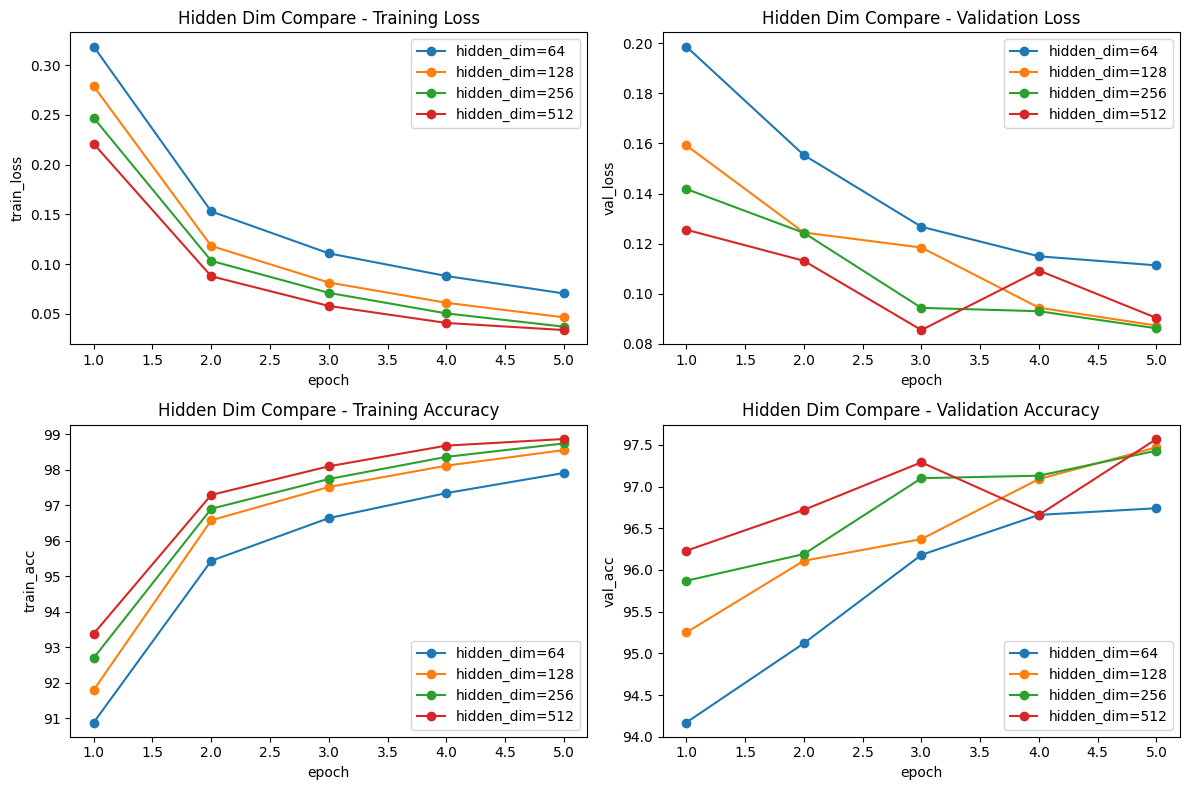

In [30]:
# 统一绘制 4 张曲线（2×2 子图，类似于下图）。
plot_compare_grid(width_histories, title_prefix="Hidden Dim Compare")


### 练习 4：不同激活函数对比

建议比较：`relu`、`sigmoid`、`tanh`、`leaky_relu`。  
其他参数保持和基线一致。

下面只给出 `relu` 的示例，请仿照补充其他激活函数。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线。


In [31]:
# 示例：激活函数为 relu
model_relu, history_relu, _ = run_experiment(
    exp_name="activation=relu",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",     # 本练习只修改激活函数
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories = {}
activation_histories["activation=relu"] = history_relu
activation_configs = {}
activation_configs["activation=relu"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_relu, last_n=3)


实验名称: activation=relu
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=3.65s
Epoch 02/5 | train_loss=0.1183, train_acc=96.58% | val_loss=0.1245, val_acc=96.11% | time=7.38s
Epoch 03/5 | train_loss=0.0816, train_acc=97.52% | val_loss=0.1184, val_acc=96.37% | time=6.31s
Epoch 04/5 | train_loss=0.0612, train_acc=98.12% | val_loss=0.0944, val_acc=97.09% | time=3.44s
Epoch 05/5 | train_loss=0.0466, train_acc=98.55% | val_loss=0.0873, val_acc=97.47% | time=3.44s
训练总耗时: 24.21 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0816 |    97.52% |   0.1184 |  96.37% |    6.31
    4 |     0.0612 |    98.12% |   0.0944 |  97.09% |    3.44
    5 |     0.0466 |    98.55% |   0.0873 |  97.47% |    3.44


In [32]:
model_sigmoid, history_sigmoid, _ = run_experiment(
    exp_name="activation=sigmoid",
    batch_size=64,
    hidden_dims=[128],
    activation_name="sigmoid",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories["activation=sigmoid"] = history_sigmoid
activation_configs["activation=sigmoid"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "sigmoid",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_sigmoid, last_n=3)


实验名称: activation=sigmoid
batch_size: 64
hidden_dims: [128]
activation_name: sigmoid
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.4314, train_acc=89.02% | val_loss=0.2515, val_acc=92.68% | time=3.64s
Epoch 02/5 | train_loss=0.1965, train_acc=94.39% | val_loss=0.1939, val_acc=94.34% | time=3.68s
Epoch 03/5 | train_loss=0.1449, train_acc=95.93% | val_loss=0.1612, val_acc=95.21% | time=3.59s
Epoch 04/5 | train_loss=0.1133, train_acc=96.90% | val_loss=0.1390, val_acc=95.96% | time=4.83s
Epoch 05/5 | train_loss=0.0907, train_acc=97.52% | val_loss=0.1261, val_acc=96.19% | time=3.62s
训练总耗时: 19.36 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1449 |    95.93% |   0.1612 |  95.21% |    3.59
    4 |     0.1133 |    96.90% |   0.1390 |  95.96% |    4.83
    5 |     0.0907 |    97.52% |   0.1261 |  96.19% |    3.62


In [33]:
model_tanh, history_tanh, _ = run_experiment(
    exp_name="activation=tanh",
    batch_size=64,
    hidden_dims=[128],
    activation_name="tanh",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories["activation=tanh"] = history_tanh
activation_configs["activation=tanh"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "tanh",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_tanh, last_n=3)


实验名称: activation=tanh
batch_size: 64
hidden_dims: [128]
activation_name: tanh
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2960, train_acc=91.58% | val_loss=0.1907, val_acc=94.34% | time=4.96s
Epoch 02/5 | train_loss=0.1411, train_acc=95.94% | val_loss=0.1491, val_acc=95.65% | time=3.50s
Epoch 03/5 | train_loss=0.0993, train_acc=97.22% | val_loss=0.1262, val_acc=96.16% | time=3.56s
Epoch 04/5 | train_loss=0.0765, train_acc=97.83% | val_loss=0.1194, val_acc=96.40% | time=3.44s
Epoch 05/5 | train_loss=0.0589, train_acc=98.38% | val_loss=0.1127, val_acc=96.44% | time=4.39s
训练总耗时: 19.85 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0993 |    97.22% |   0.1262 |  96.16% |    3.56
    4 |     0.0765 |    97.83% |   0.1194 |  96.40% |    3.44
    5 |     0.0589 |    98.38% |   0.1127 |  96.44% |    4.39


In [34]:
model_leaky, history_leaky, _ = run_experiment(
    exp_name="activation=leaky_relu",
    batch_size=64,
    hidden_dims=[128],
    activation_name="leaky_relu",
    dropout_p=0.0,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
activation_histories["activation=leaky_relu"] = history_leaky
activation_configs["activation=leaky_relu"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "leaky_relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_leaky, last_n=3)


实验名称: activation=leaky_relu
batch_size: 64
hidden_dims: [128]
activation_name: leaky_relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2807, train_acc=91.70% | val_loss=0.1647, val_acc=95.05% | time=7.26s
Epoch 02/5 | train_loss=0.1212, train_acc=96.45% | val_loss=0.1263, val_acc=96.26% | time=3.44s
Epoch 03/5 | train_loss=0.0833, train_acc=97.41% | val_loss=0.1182, val_acc=96.42% | time=3.45s
Epoch 04/5 | train_loss=0.0635, train_acc=97.98% | val_loss=0.0967, val_acc=97.08% | time=3.30s
Epoch 05/5 | train_loss=0.0490, train_acc=98.45% | val_loss=0.0928, val_acc=97.22% | time=3.27s
训练总耗时: 20.73 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0833 |    97.41% |   0.1182 |  96.42% |    3.45
    4 |     0.0635 |    97.98% |   0.0967 |  97.08% |    3.30
    5 |     0.0490 |    98.45% |   0.0928 |  97.22% |    3.27


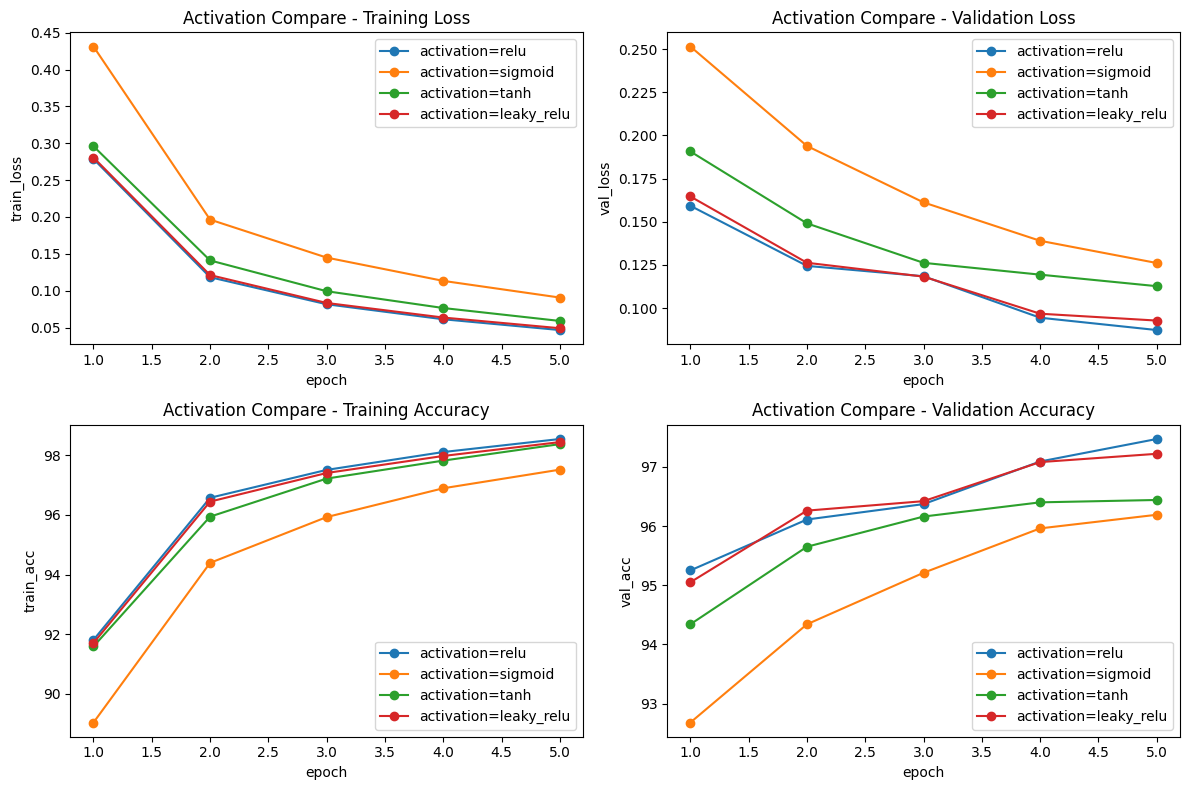

In [35]:
# 统一绘制 4 张曲线（2×2 子图，类似于下图）。
plot_compare_grid(activation_histories, title_prefix="Activation Compare")


### 练习 5：Dropout 对比

建议比较：无 Dropout、`p=0.2`、`p=0.5`。  
观察训练集与验证集之间的差距，分析是否出现过拟合。

下面只给出无 Dropout 的示例，请仿照补充 `p=0.2` 和 `p=0.5`。  
完成后请统一绘制 `train_loss / val_loss / train_acc / val_acc` 四类曲线，并重点关注 `train-val` 的差距。


In [36]:
# 示例：无 Dropout
model_dropout0, history_dropout0, _ = run_experiment(
    exp_name="dropout_p=0.0",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.0,          # 本练习只修改 dropout_p
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
dropout_histories = {}
dropout_histories["dropout_p=0.0"] = history_dropout0
dropout_configs = {}
dropout_configs["dropout_p=0.0"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.0,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_dropout0, last_n=3)


实验名称: dropout_p=0.0
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2787, train_acc=91.80% | val_loss=0.1593, val_acc=95.25% | time=3.75s
Epoch 02/5 | train_loss=0.1183, train_acc=96.58% | val_loss=0.1245, val_acc=96.11% | time=4.86s
Epoch 03/5 | train_loss=0.0816, train_acc=97.52% | val_loss=0.1184, val_acc=96.37% | time=6.30s
Epoch 04/5 | train_loss=0.0612, train_acc=98.12% | val_loss=0.0944, val_acc=97.09% | time=3.52s
Epoch 05/5 | train_loss=0.0466, train_acc=98.55% | val_loss=0.0873, val_acc=97.47% | time=3.47s
训练总耗时: 21.91 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0816 |    97.52% |   0.1184 |  96.37% |    6.30
    4 |     0.0612 |    98.12% |   0.0944 |  97.09% |    3.52
    5 |     0.0466 |    98.55% |   0.0873 |  97.47% |    3.47


In [37]:
model_dropout02, history_dropout02, _ = run_experiment(
    exp_name="dropout_p=0.2",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.2,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
dropout_histories["dropout_p=0.2"] = history_dropout02
dropout_configs["dropout_p=0.2"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.2,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_dropout02, last_n=3)


实验名称: dropout_p=0.2
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.2
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.3107, train_acc=90.78% | val_loss=0.1677, val_acc=94.97% | time=4.19s
Epoch 02/5 | train_loss=0.1510, train_acc=95.46% | val_loss=0.1295, val_acc=96.11% | time=3.61s
Epoch 03/5 | train_loss=0.1160, train_acc=96.43% | val_loss=0.1191, val_acc=96.20% | time=3.66s
Epoch 04/5 | train_loss=0.0953, train_acc=97.05% | val_loss=0.1018, val_acc=96.90% | time=3.53s
Epoch 05/5 | train_loss=0.0830, train_acc=97.46% | val_loss=0.0920, val_acc=97.23% | time=3.81s
训练总耗时: 18.80 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1160 |    96.43% |   0.1191 |  96.20% |    3.66
    4 |     0.0953 |    97.05% |   0.1018 |  96.90% |    3.53
    5 |     0.0830 |    97.46% |   0.0920 |  97.23% |    3.81


In [38]:
model_dropout05, history_dropout05, _ = run_experiment(
    exp_name="dropout_p=0.5",
    batch_size=64,
    hidden_dims=[128],
    activation_name="relu",
    dropout_p=0.5,
    learning_rate=0.001,
    epochs=5,
    verbose=True,
)
dropout_histories["dropout_p=0.5"] = history_dropout05
dropout_configs["dropout_p=0.5"] = {
    "batch_size": 64,
    "hidden_dims": [128],
    "activation_name": "relu",
    "dropout_p": 0.5,
    "learning_rate": 0.001,
    "epochs": 5,
    "verbose": True,
}
print("\n最后 3 个 epoch 结果：")
print_history_table(history_dropout05, last_n=3)


实验名称: dropout_p=0.5
batch_size: 64
hidden_dims: [128]
activation_name: relu
dropout_p: 0.5
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.4057, train_acc=87.76% | val_loss=0.1971, val_acc=94.13% | time=5.66s
Epoch 02/5 | train_loss=0.2307, train_acc=93.25% | val_loss=0.1482, val_acc=95.65% | time=8.92s
Epoch 03/5 | train_loss=0.1975, train_acc=94.05% | val_loss=0.1348, val_acc=95.91% | time=5.44s
Epoch 04/5 | train_loss=0.1766, train_acc=94.67% | val_loss=0.1259, val_acc=96.32% | time=3.44s
Epoch 05/5 | train_loss=0.1633, train_acc=95.03% | val_loss=0.1174, val_acc=96.67% | time=3.34s
训练总耗时: 26.80 秒

最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.1975 |    94.05% |   0.1348 |  95.91% |    5.44
    4 |     0.1766 |    94.67% |   0.1259 |  96.32% |    3.44
    5 |     0.1633 |    95.03% |   0.1174 |  96.67% |    3.34


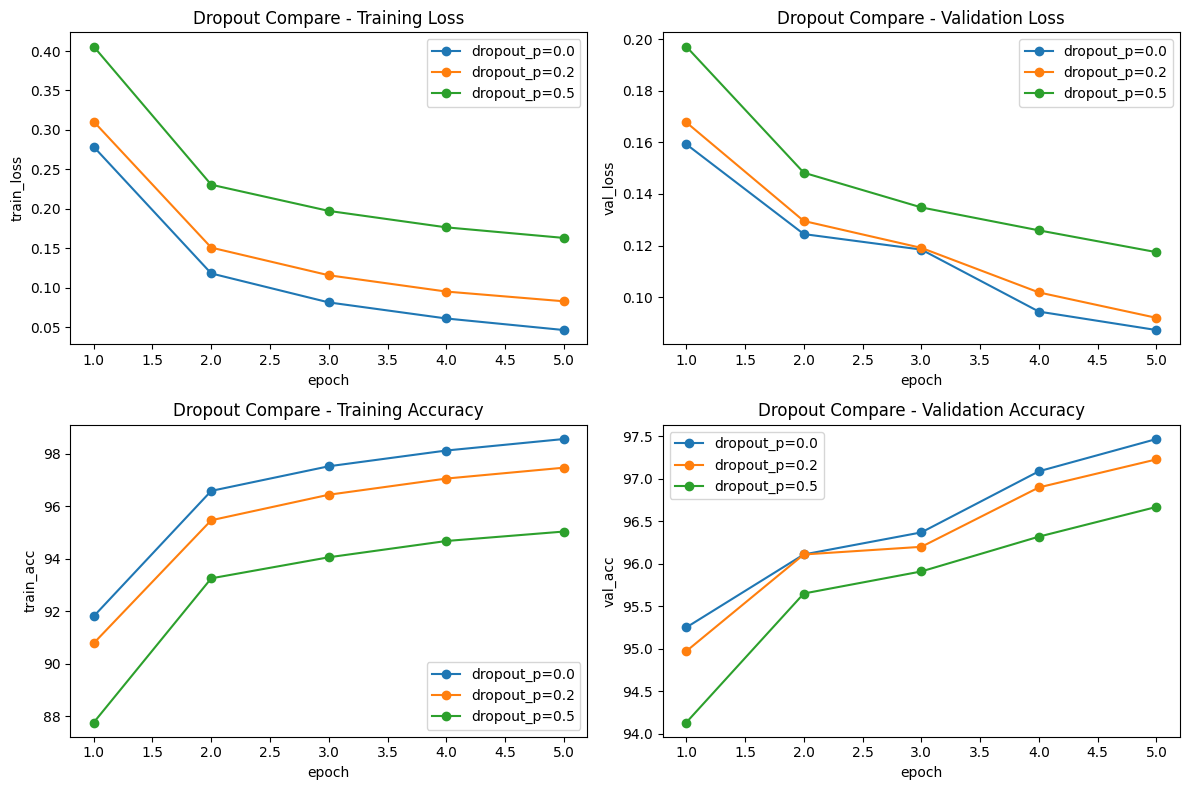

In [39]:
# 统一绘制 4 张曲线（2×2 子图，类似于下图），并结合 train-val 差距分析是否过拟合。
plot_compare_grid(dropout_histories, title_prefix="Dropout Compare")


### 练习 6：不同调参方向的最佳单变量结果对比

在每一类单变量实验中，请根据验证集结果选出该类表现最好的设置。

例如：
- batch size 中选出最优的一个
- 网络深度中选出最优的一个
- 神经元数量中选出最优的一个
- 激活函数中选出最优的一个
- Dropout 中选出最优的一个

然后将这些“最佳单变量结果”放在一起绘制对比曲线，比较不同调参方向对模型性能的影响。

建议继续绘制：
- 训练损失曲线
- 验证损失曲线
- 训练准确率曲线
- 验证准确率曲线

**说明：若不同调参方向的最佳设置恰好相同，或者某个方向的最佳设置与基线相同，部分曲线可能重合，这是正常现象。** 


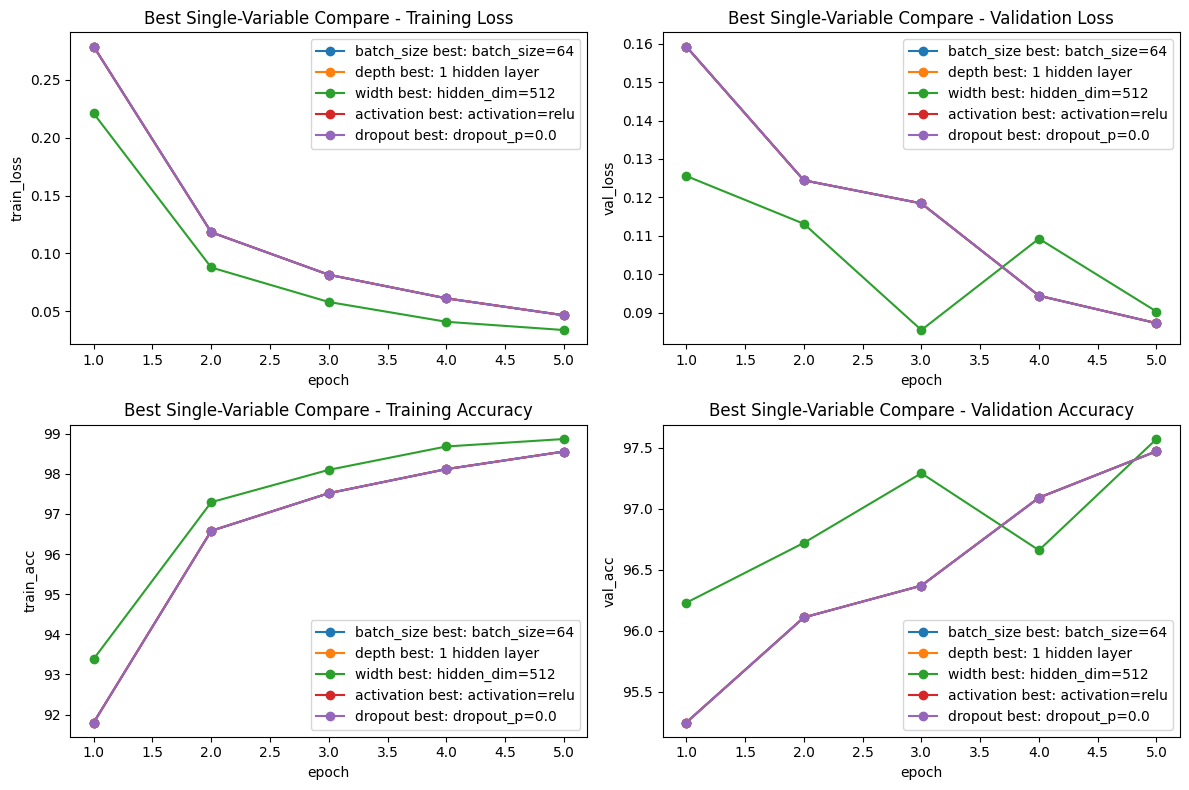

In [40]:
def pick_best(histories, configs, metric="val_acc"):
    best_label, best_history = max(
        histories.items(),
        key=lambda kv: max(kv[1][metric]),
    )
    best_config = configs[best_label]
    return best_label, best_history, best_config

best_candidates = []
best_histories = {}

label, history, config = pick_best(batch_size_histories, batch_size_configs)
best_candidates.append(("batch_size", label, history, config))
best_histories[f"batch_size best: {label}"] = history

label, history, config = pick_best(depth_histories, depth_configs)
best_candidates.append(("depth", label, history, config))
best_histories[f"depth best: {label}"] = history

label, history, config = pick_best(width_histories, width_configs)
best_candidates.append(("width", label, history, config))
best_histories[f"width best: {label}"] = history

label, history, config = pick_best(activation_histories, activation_configs)
best_candidates.append(("activation", label, history, config))
best_histories[f"activation best: {label}"] = history

label, history, config = pick_best(dropout_histories, dropout_configs)
best_candidates.append(("dropout", label, history, config))
best_histories[f"dropout best: {label}"] = history

plot_compare_grid(best_histories, title_prefix="Best Single-Variable Compare")


### 思考与分析

完成本练习后，可以思考下面几个问题：

- 不同调参方向中，哪一类改动对模型性能影响最明显？
- 收敛速度更快的模型，最终验证效果是否一定更好？
- 训练集准确率更高，是否一定代表模型泛化能力更强？

### 最终测试

完成调参后，选择验证集表现较好的模型，在测试集上评估一次。  
把最终测试准确率写入实验报告。


In [41]:
def pick_overall_best(candidates, metric="val_acc"):
    return max(candidates, key=lambda item: max(item[2][metric]))

best_category, best_label, best_history, best_config = pick_overall_best(best_candidates)
print("Selected final config:", f"{best_category}: {best_label}")

final_model, final_history, final_test_loader = run_experiment(
    exp_name=f"final_model({best_category}: {best_label})",
    **best_config,
)

criterion = nn.CrossEntropyLoss()
final_test_loss, final_test_acc = evaluate(final_model, final_test_loader, criterion)

print("\n最终模型最后 3 个 epoch 结果：")
print_history_table(final_history, last_n=3)

print(f"Final test loss: {final_test_loss:.4f}")
print(f"Final test accuracy: {final_test_acc:.2f}%")


Selected final config: width: hidden_dim=512
实验名称: final_model(width: hidden_dim=512)
batch_size: 64
hidden_dims: [512]
activation_name: relu
dropout_p: 0.0
learning_rate: 0.001
epochs: 5
Epoch 01/5 | train_loss=0.2209, train_acc=93.39% | val_loss=0.1256, val_acc=96.23% | time=4.25s
Epoch 02/5 | train_loss=0.0878, train_acc=97.29% | val_loss=0.1131, val_acc=96.72% | time=8.37s
Epoch 03/5 | train_loss=0.0580, train_acc=98.10% | val_loss=0.0855, val_acc=97.29% | time=6.97s
Epoch 04/5 | train_loss=0.0410, train_acc=98.68% | val_loss=0.1093, val_acc=96.66% | time=3.48s
Epoch 05/5 | train_loss=0.0338, train_acc=98.87% | val_loss=0.0903, val_acc=97.57% | time=3.40s
训练总耗时: 26.46 秒

最终模型最后 3 个 epoch 结果：
epoch | train_loss | train_acc | val_loss | val_acc | time(s)
-------------------------------------------------------------
    3 |     0.0580 |    98.10% |   0.0855 |  97.29% |    6.97
    4 |     0.0410 |    98.68% |   0.1093 |  96.66% |    3.48
    5 |     0.0338 |    98.87% |   0.0903 |  97

## 四、附加题（选做）



### 附加题 1：联合调参探索

要求：在前面单变量调参实验的基础上，**同时调整多个参数**，设计新的模型配置，并与基线模型或单变量实验结果进行对比。

提示：
- 可尝试组合各类实验中表现较好的参数设置；
- 例如同时调整 batch size、网络深度、神经元数量、激活函数、Dropout 等。

注意：
- 前面选出的“最佳单变量结果”，是在其他参数保持基线不变的前提下得到的。
- 因此，各类实验中分别选出的最佳设置，直接组合后不一定仍然是最优模型；有时效果可能更好，也可能变差。
- 本题重在观察联合调参后的效果变化，并做简要分析。

In [42]:
# TODO：选做。
# 尝试联合调参：同时修改多个参数，设计新的模型配置。


### 附加题 2：数据增强

要求：只**对训练集使用数据增强**，验证集和测试集不要使用随机增强。

因为验证/测试阶段需要使用稳定、可重复的数据来客观评估模型性能。

可以尝试：

- `transforms.RandomRotation(...)`
- `transforms.RandomCrop(...)`
- 其他合理的图像增强方法

观察增强前后验证集或测试集准确率的变化。


In [43]:
# TODO：选做。
# 只给训练集添加随机增强，验证集和测试集仍使用普通 transform。


### 附加题 3：自定义网络结构

设计不同于基础全连接BP 网络的模型，并与基线模型对比。并考虑添加以下内容设计：

- 加入 BatchNorm
- 加入卷积层 Conv2d 和池化层 MaxPool2d
- 设计更深或更宽的网络
- 尝试残差连接等拓展结构

注意：不要求全部实现，任选一种合理扩展即可。


In [44]:
# TODO：选做。
# 设计教材上的BP 网络模型，并比较验证集/测试集表现。
